In [2]:
using Revise
using ConjugateHeatTransfer
using CairoMakie
using LinearAlgebra
using QuadGK
using PolygonOps
using StaticArrays

In [3]:
# Parameters
N_bie = 32; # number of points per slit for BIE
potential_flow_atol = 1e-6;
density_atol = 1e-6;
solve_quad(args...) = quadgk(args...; atol=1e-12, rtol=1e-12)[1];
plot_quad(args...) = quadgk(args...; atol=1e-5, rtol=1e-5)[1];

# Bodies
zc1 = -2;
shape1(θ) = exp(im*θ);
temp1(θ) = 1;
b1 = DirichletBody(zc1, θ->zc1+shape1(θ), θ->temp1(θ));

zc2 = 2;
shape2(θ) = exp(im*θ);
temp2(θ) = 1
b2 = DirichletBody(zc2, θ->zc2+shape2(θ), θ->temp2(θ));

bodies = [b1, b2];

In [4]:
function solve_potential_flow(bodies)
    t0 = time();
    W = adaptive_laurent_potential_flow(bodies; atol=potential_flow_atol);
    println("Solved potential flow (", round(time()-t0, digits=3), " s)");
    t0 = time();
    reparametrize!(bodies, W; atol=potential_flow_atol);
    println("Joukowsky reparametrization done (", round(time()-t0, digits=3), " s)");
    return W
end

function solve_heat_transfer(bodies, Pe)
    # Panels
    panels = [DirichletPanel(body) for body in bodies];
    t0 = time();
    solve_densities!(panels, N_bie; Pe=Pe, atol=density_atol, quadrature=solve_quad);
    println("Densities solved (", round(time()-t0, digits=3), " s)");
    return panels
end

solve_heat_transfer (generic function with 1 method)

In [5]:
# Solve potential flow
W = solve_potential_flow(bodies);

# Compute fluxes for a range of Peclet numbers
Pe_vec = collect(exp10.(LinRange(-6, 6, 13)));
fluxes = Vector{Vector{Float64}}();
for Pe in Pe_vec
    println("----------------------------------------------------------------")
    println("Solving for Pe = ", Pe)
    panels = solve_heat_transfer(bodies, Pe);
    # Fluxes
    println("Fluxes: ", [p.flux for p in panels])
    println("Total flux: ", sum([p.flux for p in panels]))
    push!(fluxes, [p.flux for p in panels])
end

flux_array = reduce(hcat, fluxes)
f1 = flux_array[1,:]
f2 = flux_array[2,:];

  Q shape: (384, 132)
  Fitting error: 1.7763568394002505e-15
  N_laurent = 32, error = 1.32e-15
Solved potential flow (1.429 s)
  w coeffs: 25
  dθ coeffs: 20
  zη coeffs: 23
  Tη coeffs: 1
  w coeffs: 25
  dθ coeffs: 30
  zη coeffs: 24
  Tη coeffs: 1
Joukowsky reparametrization done (3.763 s)
----------------------------------------------------------------
Solving for Pe = 1.0e-6
  g coeffs: 0
  g coeffs: 0
size(M) = (128, 64)
cond(M) = 865.4729346983647
Densities solved (9.967 s)
Fluxes: [0.22599734686109363, 0.2259896876469927]
Total flux: 0.4519870345080863
----------------------------------------------------------------
Solving for Pe = 1.0e-5
  g coeffs: 0
  g coeffs: 0
size(M) = (128, 64)
cond(M) = 722.7424065866488
Densities solved (2.772 s)
Fluxes: [0.27089579453985296, 0.2708204022091979]
Total flux: 0.5417161967490509
----------------------------------------------------------------
Solving for Pe = 0.0001
  g coeffs: 0
  g coeffs: 0
size(M) = (128, 64)
cond(M) = 580.0274652

In [6]:
function evaluate_W(W, z)
    t0 = time();
    w = reshape(W(vec(z)), size(z));
    println("Flow evaluated (", round(time()-t0, digits=3), " s)");
    return w
end

function check_inside(body, z)
    poly = body.zθ.(LinRange(0, 2π, 100))
    poly[end] = poly[1]
    poly = [[real(z), imag(z)] for z in poly]
    return inpolygon([real(z), imag(z)], poly; in=true, on=false, out=false)
end

function evaluate_T(panels, w, Pe)
    bodies = [panel.body for panel in panels]
    # Mask interiors before evaluating temperature
    φ = real(w);
    ψ = imag(w);
    # for body in bodies
    #     check_body(z) = check_inside(body, z)
    #     interior = check_body.(z)
    #     φ[interior] .= 0
    #     ψ[interior] .= 0
    # end
    # Evaluate temperature
    t0 = time();
    T = EvaluateSystem(φ, ψ, panels; Pe=Pe, quadrature=plot_quad);
    println("Temperature evaluated (", round(time()-t0, digits=3), " s)");
    # Mask interiors
    for body in bodies
        check_body(z) = check_inside(body, z)
        interior = check_body.(z)
        φ[interior] .= NaN
        ψ[interior] .= body.ψ
        T[interior] .= NaN
    end
    return T
end

evaluate_T (generic function with 1 method)

In [7]:
# Evaluate T(z)
gridsize = 300
Lz = 10.5

x = collect(LinRange(-Lz, Lz, gridsize));
y = collect(LinRange(-Lz, Lz, gridsize));
z = x' .+ im*y;

Pe_plot = [1e-2, 1e2]

panels1 = solve_heat_transfer(bodies, Pe_plot[1]);
w1 = evaluate_W(W, z);
T1 = evaluate_T(panels1, w1, Pe_plot[1]);

panels2 = solve_heat_transfer(bodies, Pe_plot[2]);
w2 = evaluate_W(W, z);
T2 = evaluate_T(panels2, w2, Pe_plot[2]);

  g coeffs: 0
  g coeffs: 0
size(M) = (128, 64)
cond(M) = 294.83822119652507
Densities solved (2.816 s)
Flow evaluated (0.201 s)
Temperature evaluated (2.242 s)
  g coeffs: 0
  g coeffs: 0
size(M) = (128, 64)
cond(M) = 13.744009790443863
Densities solved (1.935 s)
Flow evaluated (0.203 s)
Temperature evaluated (0.867 s)


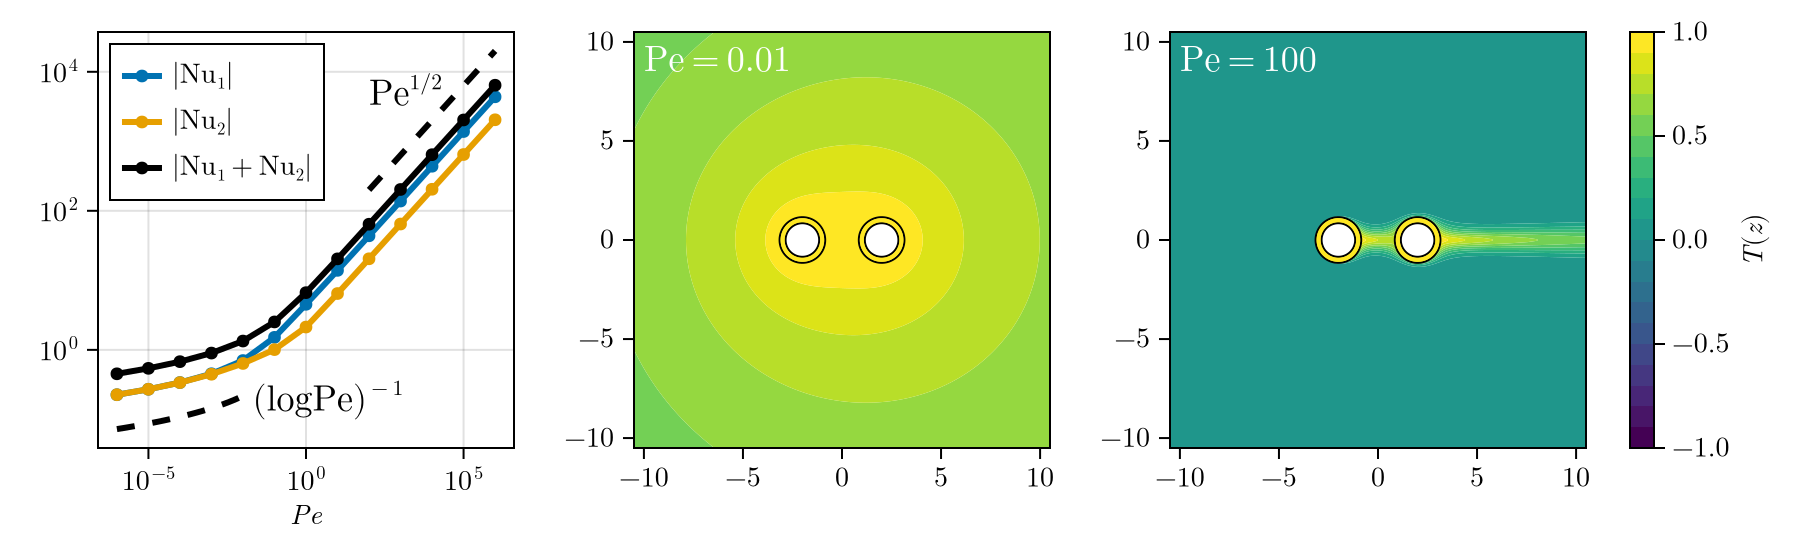

In [18]:
# Plot
fig = Figure(size=(900, 280));
set_theme!(theme_latexfonts());

# Levels
T_levels = LinRange(-1, 1, 21);
Pe_low = 10 .^ LinRange(-6, -2, 20)
Pe_high = 10 .^ LinRange(2, 6, 20)

# Left panel: fluxes
ax = Axis(fig[1,1], xscale=log10, yscale=log10, aspect=1);
line1 = scatterlines!(ax, Pe_vec, abs.(f1), linewidth=3, marker=:circle, label=L"|\mathrm{Nu}_1|");
line2 = scatterlines!(ax, Pe_vec, abs.(f2), linewidth=3, marker=:circle, label=L"|\mathrm{Nu}_2|");
line3 = scatterlines!(ax, Pe_vec, abs.(f1+f2), linewidth=3, marker=:circle, color=:black, label=L"|\mathrm{Nu}_1 + \mathrm{Nu}_2|");
lines!(ax, Pe_low, -1 ./ log.(Pe_low), linewidth=3, color=:black, linestyle=:dash)
lines!(ax, Pe_high, 20*Pe_high.^(1/2), linewidth=3, color=:black, linestyle=:dash)
text!(ax, L"(\mathrm{log Pe})^{-1}", position=(2e-2, 4e-1), align=(:left, :top), color=:black, fontsize=18)
text!(ax, L"\mathrm{Pe}^{1/2}", position=(1e2, 1e4), align=(:left, :top), color=:black, fontsize=18)
ax.xlabel = L"Pe"
axislegend(position=:lt)

# Plot temperature fields
for (i, (Pe_text, T, panels)) in enumerate([("0.01", T1, panels1), ("100", T2, panels2)])
    ax = Axis(fig[1,1+i], aspect=DataAspect());
    xlims!(ax, -Lz, Lz)
    ylims!(ax, -Lz, Lz)
    #hidedecorations!(ax, grid=false)
    # Background for body interiors
    poly!(ax, [(-Lz, -Lz), (Lz, -Lz), (Lz, Lz), (-Lz, Lz)], color=:white, rasterize=true)
    # Temperature contours
    co = contourf!(ax, x, y, T', levels=T_levels, nan_color=:black);
    # Label with Peclet number
    text!(ax, L"\mathrm{Pe} = %$Pe_text", position=(-Lz+0.5, Lz-0.5), align=(:left, :top), color=:white, fontsize=18)
    # Bodies
    colorrange = (minimum(co._computed_levels.val), maximum(co._computed_levels.val));
    θp = LinRange(0, 2π, 100);
    for body in bodies
        boundary = body.zθ.(θp)
        temp = body.Tθ.(θp)
        lines!(ax, real(boundary), imag(boundary), color=:black, linewidth=4, colorrange=colorrange)
        lines!(ax, real(boundary), imag(boundary), color=temp, linewidth=2, colorrange=colorrange)
        # Replot with shift to get rid of color artifacts
        boundary = body.zθ.(θp.+π/100)
        temp = body.Tθ.(θp.+π/100)
        lines!(ax, real(boundary), imag(boundary), color=temp, linewidth=2, colorrange=colorrange)
    end
    # Colorbar
    if i == 2
        Colorbar(fig[1,4], co, label=L"$T(z)$");
    end
end

save("fig_twobody_scaling_same.pdf", fig);
fig